# Liquidity Transformation: why an ETF can be liquid even if it holds illiquid assets

**Course:** Advanced Fixed Income and Credit — Supplementary analysis
**Theme:** *Market microstructure insights*

## Research question

> **If an ETF holds an illiquid underlying, how can the ETF itself be liquid?**

## Where this analysis fits

The main analysis answers this question by describing the institutional
mechanism at its two levels:

1. **Secondary market** (order-driven) — investors trade ETF shares among
   themselves; market makers provide liquidity continuously, quoting
   bid/ask, and hedge their inventory risk through **continuous hedging**
   (correlated liquid instruments, not the individual underlying bonds on
   every trade).
2. **Primary market** — when the market maker's inventory becomes too
   unbalanced, Authorized Participants (APs) absorb it through the
   **creation/redemption** mechanism, the only point where net demand or
   supply for ETF shares actually touches the underlying bonds.

This notebook **does not replace** that description — it complements it from
a different, purely statistical angle: instead of describing *the
mechanism* (hedging, creation/redemption), we measure **its fingerprint in
price data**. If the institutional story is correct, it must leave an
observable trace: the ETF price (driven by continuous trading and the
market maker's hedging on the secondary market) should behave like a
"fresh" process, while the NAV (which depends on the often non-synchronous
valuation of individual bonds) should behave like a "stale" process. This is
exactly what we test.

## How to read this notebook

Every technical block (a model, a proposition, a simulation) is followed by
a **"In plain language"** paragraph that restates it without formulas —
meant to be reused as-is in an oral presentation.

## Pipeline

A purely econometric analysis: two statistical models, two estimators (one
a point estimate, one a formal hypothesis test), validated on synthetic
data and then applied to real data. No regime classification (HMM) — that
stays in the main project, applied to the premium/discount.

1. **The two starting models** — before measuring anything, we explicitly
   fix the statistical model for the NAV and the one for the ETF price,
   motivated by the institutional story above
2. **Estimators** — rolling lag-1 autocorrelation, the variance ratio
   (Lo–MacKinlay, 1988), and the Ljung–Box test (formal significance of the
   autocorrelation)
3. **Synthetic validation** — we check that the estimators correctly
   recover the known parameters of the two models, and that the test
   rejects/fails to reject the null hypothesis as expected
4. **Rolling diagnostics** — do the estimates track a time-varying
   parameter, on a synthetic path with a known regime schedule
5. **Real data** — historical NAV of LQD and HYG (no network required);
   cross-fund comparison (hypothesis: high-yield staler than
   investment-grade)
6. **Network extension** — full NAV-vs-price comparison on real data, to be
   run locally with `DEMO = False`

### Libraries and plotting configuration

In [1]:
%matplotlib inline
from __future__ import annotations

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore", category=UserWarning)

# If running in Colab and a package is missing, uncomment:
# !pip install yfinance --quiet

os.makedirs("../figures", exist_ok=True)  # figures below are saved here (sibling folder)

np.random.seed(7)
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Configuration

In [2]:
# ============================================================================
# CONFIGURATION - edit here to switch between demo and real data
# ============================================================================
DEMO = True              # True = synthetic data only (no network needed)
TICKERS = ["LQD", "HYG"]  # real-data tickers, used only when DEMO = False
NAV_CSV = {               # local NAV history files already parsed from iShares exports
    "LQD": "../data/lqd_nav_history.csv",
    "HYG": "../data/hyg_nav_history.csv",
}

ROLL_WINDOW = 60          # trading days, rolling window for autocorrelation / VR
VR_HORIZON = 5            # q in the Lo-MacKinlay variance ratio VR(q)
LB_LAGS = 10              # number of lags tested jointly by the Ljung-Box test
RANDOM_SEED = 7

## 2. The two starting models

Before estimating or simulating anything, we explicitly fix **two distinct
statistical models** — one for the return reported in the NAV, one for the
ETF's price return — motivated directly by the main analysis's two-level
institutional story. Let $r^\ast_t$ be the "true" (economic, unobservable)
return of the bond basket on day $t$: both models below are written as
functions of $r^\ast_t$, but they "see" it in different ways.

### 2.1 NAV model: stale valuation (Getmansky–Lo–Makarov, 2004)

The NAV is computed by the fund's administrator by summing the prices of
the individual bonds in the basket — the **primary/valuation** side of the
market. Many bonds do not trade every day: when they don't, the pricing
desk uses a matrix price based on the last observed price. The return
**reported** in the NAV is therefore not $r^\ast_t$, but a weighted average
of recent true returns,
$$
r^{NAV}_t = \sum_{j=0}^{k-1} \theta_j  r^\ast_{t-j}, \qquad \theta_j \ge 0,\quad \sum_{j=0}^{k-1}\theta_j = 1.
$$
We will use geometrically decaying weights, $\theta_j = (1-\phi)\phi^{j}$,
with $\phi\in[0,1)$ the **smoothing/staleness parameter** ($\phi=0$: no
smoothing; $\phi\to 1$: very persistent smoothing).

**Why this generates autocorrelation: a minimal example.** The simplest
case, half the weight on today, half on yesterday:
$r^{NAV}_t = 0.5 r^\ast_t + 0.5 r^\ast_{t-1}$. With (independent) true
returns on days 1–4 equal to $+2\%,-1\%,+3\%,+1\%$:
\begin{align*}
r^{NAV}_2 &= 0.5(-1\%)+0.5(2\%) = 0.5\%, \\
r^{NAV}_3 &= 0.5(3\%)+0.5(-1\%) = 1.0\%, \\
r^{NAV}_4 &= 0.5(1\%)+0.5(3\%) = 2.0\%.
\end{align*}
$r^{NAV}_3$ and $r^{NAV}_4$ share the same ingredient — the $+3\%$ shock
from day 3, once as "today", again as "yesterday" the next day. That shock
is not consumed in one shot: half of it lands in today's NAV, the other
half also drags tomorrow's NAV upward. It is this overlap of ingredients
between consecutive observations that generates positive autocorrelation.

**Key result.** In the limit $k\to\infty$, $r^{NAV}_t$ is $MA(\infty)$ with
$\gamma(h) = \sigma^2\sum_j\theta_j\theta_{j+h}$; for the geometric weights,
$$
\gamma(h) = \sigma^2 \frac{(1-\phi)^2}{1-\phi^2} \phi^{h}
\quad\Longrightarrow\quad
\rho_1 := \frac{\gamma(1)}{\gamma(0)} = \phi.
$$
The NAV's lag-1 autocorrelation is **exactly** $\phi$ — an exact identity
of the model, not an analogy.

> **In plain language.** The NAV doesn't immediately "know" what the bond
> basket is really worth today, because many of its constituents haven't
> traded: it's still using an old price. True information therefore arrives
> spread out over several days instead of all at once — and this makes a
> "good" day for the NAV tend to be followed by another slightly "good"
> day, even though economically there was only one shock. The more
> illiquid the bonds are (the higher $\phi$ is), the longer this effect
> persists.

### 2.2 ETF price model: secondary market and market-maker hedging

The ETF's price forms on the order-driven secondary market, where most
trading happens **between investors through the market maker**, without
ever touching the underlying bonds. The market maker supplies liquidity
continuously and hedges the resulting inventory risk with **continuous
hedging** — typically using correlated liquid instruments (rate futures,
credit indices), not rebalancing the bond basket on every single trade.
Only when the inventory imbalance becomes too large does the
**creation/redemption** mechanism with an AP kick in, which is the point of
contact with the primary market.

We therefore model the price return as the true return plus i.i.d.
idiosyncratic noise, representing continuous hedging and secondary-market
microstructure noise:
$$
r^{P}_t = r^\ast_t + \eta_t, \qquad \eta_t \overset{\text{i.i.d.}}{\sim} \mathcal{N}(0,\sigma_\eta^2),\ \ \eta_t \perp r^\ast_s\ \ \forall s.
$$
Being the sum of two independent i.i.d.\ processes, $r^P_t$ is itself
i.i.d.: $\rho_1(r^P) = 0$ in population, by construction.

> **In plain language.** The ETF price doesn't need to wait for the bonds
> to reprice in order to update: the market maker keeps it aligned to the
> true value through its own continuous hedging on liquid instruments, day
> by day. Our model says: the ETF price tracks the true value almost
> exactly, plus some noise that leaves no "memory" from one day to the
> next — the exact opposite of the NAV.

**An honest asymmetry worth flagging.** In this form the ETF price model is
a "clean" case — an efficient-price benchmark. The classic bid-ask bounce
model (Roll, 1984) would actually imply mild *negative* autocorrelation,
not zero. We haven't included it in order to keep the control model simple
(theoretical $\rho_1$ exactly $0$); it's a natural extension if a more
realistic benchmark is wanted.

### 2.3 Variance ratio: a complementary diagnostic

$$
VR(q) = \frac{\mathrm{Var}\left(\sum_{i=0}^{q-1} r_{t-i}\right)}{q \mathrm{Var}(r_t)}.
$$
Equal to $1$ under i.i.d.\ returns (our ETF price model) and increasing in
$\phi$ for the geometric NAV model above (autocovariance decaying as
$\phi^h$, like an $AR(1)$).

> **In plain language.** It's a second way of measuring the same thing as
> the autocorrelation, but looking at a multi-day horizon instead of just
> "yesterday versus today" — useful as a robustness check, not as a
> replacement for $\hat\rho_1$.

### 2.4 Summary of the two models

| | Generated by | Market level | Expected $\rho_1$ |
|---|---|---|---|
| $r^{NAV}_t$ | Valuation (matrix pricing) of the bonds | Primary / valuation | $= \phi > 0$ |
| $r^{P}_t$ | Continuous trading + market-maker hedging | Secondary / order-driven | $\approx 0$ |

The gap between these two expected values — measurable without ever seeing
the bonds' order book — is the direct statistical evidence that answers the
research question: the ETF is liquid because its price lives predominantly
in the clean "secondary" process, not in the stale "primary/valuation"
process it is nonetheless anchored to (through the creation/redemption
mechanism, the subject of the main analysis).

## 3. Estimators and simulation of the two models

We implement the two models of Section 2 and three tools to tell them apart
in the data: rolling lag-1 autocorrelation, the variance ratio, and the
**Ljung–Box test**, which adds formal significance to what $\hat\rho_1$
measures only as a point estimate.

### The Ljung–Box test

$\hat\rho_1$ is an estimate — a number subject to sampling noise. The
Ljung–Box test asks: is that number (or more generally the autocorrelation
up to some number of lags) **statistically distinguishable from zero**, or
could it just be noise? The null hypothesis is
$H_0:\ \rho_1=\rho_2=\dots=\rho_L=0$ (no autocorrelation up to lag $L$). The
test statistic is
$$
Q = n(n+2)\sum_{k=1}^{L}\frac{\hat\rho_k^2}{n-k},
$$
which under $H_0$ is approximately distributed as a $\chi^2$ with $L$
degrees of freedom. A small $p$-value (conventionally $<0.05$) rejects
$H_0$: the observed autocorrelation is too large to be explained by
sampling noise alone.

> **In plain language.** $\hat\rho_1$ tells you *how much* autocorrelation
> there appears to be; Ljung–Box tells you whether you can *trust* that
> number — whether it's strong enough not to be explainable by pure chance,
> given how many days of data you have.

In [3]:
def make_geometric_weights(phi: float, k: int) -> np.ndarray:
    """Geometric smoothing weights theta_j = (1-phi) phi^j, renormalized to
    sum to 1 (correction for the finite-k truncation of the theoretically
    infinite MA(infinity) process). This implements the NAV model of
    Section 2.1."""
    j = np.arange(k)
    theta = (1.0 - phi) * phi**j
    theta = theta / theta.sum()
    return theta


def simulate_smoothed_fund(n: int, phi: float, k: int = 20, sigma: float = 1.0,
                            noise_ratio: float = 0.15, seed: int | None = None):
    """Simulate a fund's 'true' latent return, its smoothed/stale NAV return
    (Section 2.1 model), and its ETF market-price return (Section 2.2 model).

    Parameters
    ----------
    n : number of trading days to simulate
    phi : smoothing/staleness parameter in [0, 1); theoretical rho_1(NAV) = phi
    k : number of MA lags used for the (truncated) smoothing filter
    sigma : std dev of the true daily return
    noise_ratio : std dev of ETF idiosyncratic noise, as a fraction of sigma
    """
    rng = np.random.default_rng(seed)
    burn_in = k  # extra warm-up so the smoothing filter is fully "spun up"
    true_r = rng.normal(0.0, sigma, size=n + burn_in)

    theta = make_geometric_weights(phi, k)
    # NAV model (Sec. 2.1): obs[t] = sum_j theta_j * true_r[t-j]  <=>  causal convolution
    nav_r_full = np.convolve(true_r, theta, mode="full")[: len(true_r)]

    # ETF price model (Sec. 2.2): true return + i.i.d. idiosyncratic noise
    eta = rng.normal(0.0, sigma * noise_ratio, size=n + burn_in)
    etf_r_full = true_r + eta

    # drop the warm-up so the smoothing filter has "seen" k true lags everywhere
    true_r = true_r[burn_in:]
    nav_r = nav_r_full[burn_in:]
    etf_r = etf_r_full[burn_in:]
    return true_r, nav_r, etf_r


def rolling_autocorr_lag1(returns: pd.Series, window: int) -> pd.Series:
    """Rolling sample lag-1 autocorrelation, computed with pandas' own
    Series.autocorr (no statsmodels dependency)."""
    r = pd.Series(returns)
    return r.rolling(window).apply(lambda x: pd.Series(x).autocorr(lag=1), raw=False)


def rolling_variance_ratio(returns: pd.Series, window: int, q: int) -> pd.Series:
    """Lo-MacKinlay variance ratio VR(q), computed on a trailing rolling
    window of daily returns."""
    r = pd.Series(returns)  # keep the original index so this aligns with rolling_autocorr_lag1

    def _vr(x):
        x = pd.Series(x)
        var_1 = x.var(ddof=1)
        if var_1 == 0 or len(x) <= q:
            return np.nan
        q_returns = x.rolling(q).sum().dropna()
        var_q = q_returns.var(ddof=1)
        return var_q / (q * var_1)

    return r.rolling(window).apply(_vr, raw=False)


def ljung_box_test(returns: pd.Series, lags: int) -> tuple[float, float]:
    """Ljung-Box Q-statistic and p-value, testing H0: no autocorrelation up
    to the given number of lags. Implemented directly (no statsmodels
    dependency): Q = n(n+2) * sum_{k=1}^{lags} rho_hat(k)^2 / (n-k), which is
    asymptotically chi-squared(lags) under H0."""
    r = pd.Series(returns).dropna()
    n = len(r)
    q_stat = 0.0
    for k in range(1, lags + 1):
        rho_k = r.autocorr(lag=k)
        q_stat += rho_k**2 / (n - k)
    q_stat *= n * (n + 2)
    p_value = 1.0 - stats.chi2.cdf(q_stat, df=lags)
    return q_stat, p_value

### Check: do the estimators recover the models' parameters, and does the test confirm it?

We simulate a long sample (to reduce sampling noise) for a few values of
$\phi$ and compare the synthetic NAV's sample autocorrelation with the
theoretical value $\phi$ (model 2.1), and the synthetic ETF price's with
the theoretical value $0$ (model 2.2). We add the Ljung–Box $p$-value for
both series: we expect it to reject $H_0$ (small $p$-value) when
$\phi>0$, and to fail to reject (large $p$-value) when $\phi=0$ or for the
ETF price, where there is no true autocorrelation.

In [4]:
validation_rows = []
for i, phi_true in enumerate([0.0, 0.2, 0.4, 0.6, 0.8]):
    true_r, nav_r, etf_r = simulate_smoothed_fund(n=20_000, phi=phi_true, seed=RANDOM_SEED + i)
    rho1_nav = pd.Series(nav_r).autocorr(lag=1)
    rho1_etf = pd.Series(etf_r).autocorr(lag=1)
    _, p_nav = ljung_box_test(pd.Series(nav_r), lags=LB_LAGS)
    _, p_etf = ljung_box_test(pd.Series(etf_r), lags=LB_LAGS)
    validation_rows.append({
        "phi (true)": phi_true,
        "rho1(NAV) estimated": round(rho1_nav, 4),
        "Ljung-Box p (NAV)": "<0.0001" if p_nav < 1e-4 else round(p_nav, 4),
        "rho1(ETF) estimated": round(rho1_etf, 4),
        "Ljung-Box p (ETF)": round(p_etf, 4),
    })

validation_df = pd.DataFrame(validation_rows)
print(validation_df.to_string(index=False))

 phi (true)  rho1(NAV) estimated Ljung-Box p (NAV)  rho1(ETF) estimated  Ljung-Box p (ETF)
        0.0              -0.0054            0.5901              -0.0047             0.5799
        0.2               0.1957           <0.0001              -0.0062             0.4759
        0.4               0.3876           <0.0001              -0.0132             0.3616
        0.6               0.5986           <0.0001              -0.0031             0.9267
        0.8               0.8052           <0.0001               0.0181             0.3368


> **In plain language.** The NAV column tracks the "true $\phi$" column
> almost exactly — the estimator correctly measures how much smoothing we
> put into the model — and the test confirms it: as soon as $\phi>0$, the
> NAV's $p$-value drops to negligible values (extremely strong
> autocorrelation, impossible to get from pure noise over 20,000 days). The
> ETF price column stays close to zero throughout, with high $p$-values
> (we fail to reject $H_0$: consistent with a genuinely i.i.d. process) —
> even when the NAV's smoothing in the same scenario is very strong.
> Estimator and test tell the same story together: the two models of
> Section 2 behave exactly as expected.

## 4. Rolling diagnostics on a path with a shifting regime

We now simulate a single path in which the NAV's staleness parameter,
$\phi$, **changes over time** (low, then high, then low again, etc.),
holding model 2.2 fixed for the ETF price — to see whether the rolling
estimates (60-day window) track the change over time, not just in an
aggregate over the whole sample as in the previous test.

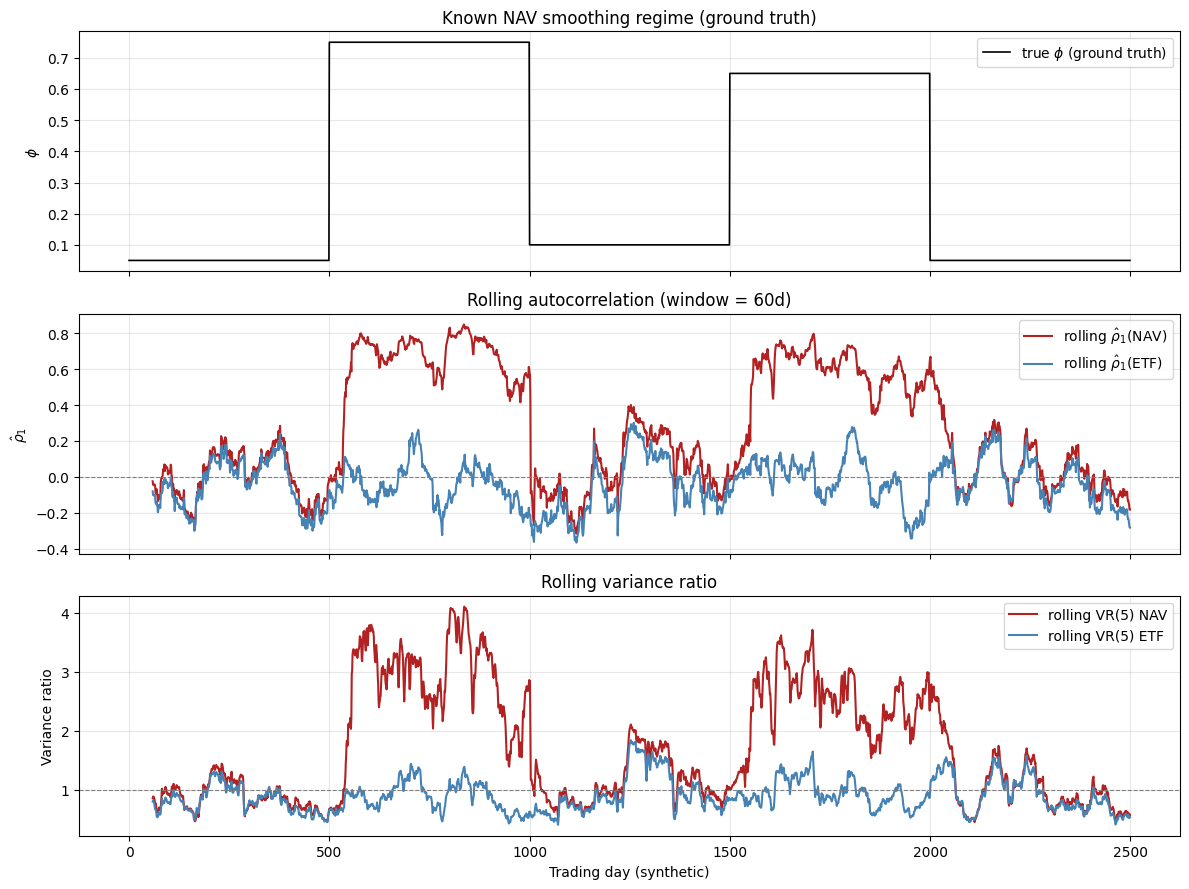

In [5]:
# Build a synthetic path with a known regime schedule: phi switches between
# a "liquid" and a "stale" value at known break points (ground truth for validation).
segment_length = 500
phi_schedule = [0.05, 0.75, 0.10, 0.65, 0.05]  # low, high, low, high, low

true_parts, nav_parts, etf_parts, true_phi_parts = [], [], [], []
for i, phi_seg in enumerate(phi_schedule):
    t_r, n_r, e_r = simulate_smoothed_fund(n=segment_length, phi=phi_seg, seed=RANDOM_SEED + i)
    true_parts.append(t_r)
    nav_parts.append(n_r)
    etf_parts.append(e_r)
    true_phi_parts.append(np.full(segment_length, phi_seg))

sim_nav_r = np.concatenate(nav_parts)
sim_etf_r = np.concatenate(etf_parts)
sim_true_phi = np.concatenate(true_phi_parts)
sim_index = np.arange(len(sim_nav_r))

rho1_nav_roll = rolling_autocorr_lag1(pd.Series(sim_nav_r), ROLL_WINDOW)
rho1_etf_roll = rolling_autocorr_lag1(pd.Series(sim_etf_r), ROLL_WINDOW)
vr_nav_roll = rolling_variance_ratio(pd.Series(sim_nav_r), ROLL_WINDOW, VR_HORIZON)
vr_etf_roll = rolling_variance_ratio(pd.Series(sim_etf_r), ROLL_WINDOW, VR_HORIZON)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(sim_index, sim_true_phi, color="black", lw=1.2, label=r"true $\phi$ (ground truth)")
axes[0].set_ylabel(r"$\phi$")
axes[0].legend(loc="upper right")
axes[0].set_title("Known NAV smoothing regime (ground truth)")

axes[1].plot(rho1_nav_roll, label=r"rolling $\hat\rho_1$(NAV)", color="firebrick")
axes[1].plot(rho1_etf_roll, label=r"rolling $\hat\rho_1$(ETF)", color="steelblue")
axes[1].axhline(0, color="gray", lw=0.8, ls="--")
axes[1].set_ylabel(r"$\hat\rho_1$")
axes[1].legend(loc="upper right")
axes[1].set_title(f"Rolling autocorrelation (window = {ROLL_WINDOW}d)")

axes[2].plot(vr_nav_roll, label=f"rolling VR({VR_HORIZON}) NAV", color="firebrick")
axes[2].plot(vr_etf_roll, label=f"rolling VR({VR_HORIZON}) ETF", color="steelblue")
axes[2].axhline(1, color="gray", lw=0.8, ls="--")
axes[2].set_ylabel("Variance ratio")
axes[2].set_xlabel("Trading day (synthetic)")
axes[2].legend(loc="upper right")
axes[2].set_title("Rolling variance ratio")

plt.tight_layout()
plt.savefig("../figures/smoothing_rolling_diagnostics_en.png", dpi=130, bbox_inches="tight")
plt.show()

> **In plain language.** The red curve (NAV) rises and falls exactly in
> step with the known regime in the panel above; the blue curve (ETF price)
> stays flat near zero throughout the simulation, regardless of what the
> NAV is doing. If the story in Section 2 is correct, this is exactly what
> we expect to see — and it is what we see.

**A large gap is not a warning sign.** Worth clarifying before moving to
real data: when $\hat\rho_1(NAV)-\hat\rho_1(ETF)$ is large, it means the
underlying is very stale (model 2.1) **and that, despite this, the ETF
price stays clean** (model 2.2 intact) — liquidity transformation is
working as it should, not breaking down. In this simulation the ETF
price's idiosyncratic noise ($\eta_t$) has constant variance by
construction: we never simulated a scenario where the mechanism truly
breaks. A genuine breakdown would show up differently — not with
$\hat\rho_1(NAV)$ rising, but with $\hat\rho_1(ETF)$ itself starting to
rise toward the NAV's level (model 2.2 stops holding, the market maker can
no longer keep the price "fresh"). That is the signal to look for in real
data as evidence of a genuine failure of the mechanism, not a large gap by
itself.

## 5. Real data: NAV of LQD and HYG (no network required)

This section applies the model 2.1 estimator to the real NAV of LQD and
HYG (already exported from iShares for the main project) — no ETF OHLCV is
needed, so it runs without network access even in `DEMO = False` mode.

The economic hypothesis: **high-yield** bonds (HYG) are typically less
liquid than **investment-grade** bonds (LQD) — so we expect HYG's NAV to
show **more** smoothing.

In [6]:
def load_real_nav(path: str) -> pd.Series:
    df = pd.read_csv(path, parse_dates=["Date"]).sort_values("Date").set_index("Date")
    nav = df["NAV"].astype(float)
    log_ret = np.log(nav).diff().dropna()
    return log_ret


real_nav_returns = {}
for ticker, path in NAV_CSV.items():
    if Path(path).exists():
        real_nav_returns[ticker] = load_real_nav(path)
        print(f"{ticker}: {len(real_nav_returns[ticker])} daily NAV log-returns "
              f"({real_nav_returns[ticker].index.min().date()} -> {real_nav_returns[ticker].index.max().date()})")
    else:
        print(f"{ticker}: NAV file '{path}' not found - skipping.")

LQD: 6079 daily NAV log-returns (2002-07-23 -> 2026-09-16)
HYG: 4897 daily NAV log-returns (2007-04-05 -> 2026-09-18)


In [7]:
real_summary_rows = []
real_rolling = {}
for ticker, ret in real_nav_returns.items():
    rho1_full = ret.autocorr(lag=1)
    vr_full = rolling_variance_ratio(ret, window=len(ret), q=VR_HORIZON).iloc[-1]
    _, p_lb = ljung_box_test(ret, lags=LB_LAGS)
    roll_rho1 = rolling_autocorr_lag1(ret, ROLL_WINDOW)
    roll_vr = rolling_variance_ratio(ret, ROLL_WINDOW, VR_HORIZON)
    real_rolling[ticker] = pd.DataFrame({"rho1": roll_rho1, "vr": roll_vr})
    real_summary_rows.append({
        "Fund": ticker,
        "N days": len(ret),
        "rho1(NAV), full-sample": round(rho1_full, 4),
        f"VR({VR_HORIZON}), full-sample": round(vr_full, 4),
        "rho1(NAV), rolling mean": round(roll_rho1.mean(), 4),
        "Ljung-Box p": "<0.0001" if p_lb < 1e-4 else round(p_lb, 4),
    })

real_summary_df = pd.DataFrame(real_summary_rows)
print(real_summary_df.to_string(index=False))

Fund  N days  rho1(NAV), full-sample  VR(5), full-sample  rho1(NAV), rolling mean Ljung-Box p
 LQD    6079                  0.0999              1.2201                   0.0235     <0.0001
 HYG    4897                  0.3409              1.9647                   0.2126     <0.0001


> **In plain language.** If HYG shows higher numbers than LQD in this
> table, that's evidence — using NAV data alone, without looking at the
> ETF price or the bonds' order book — that the high-yield basket is more
> stale/illiquid than the investment-grade one, consistent with what
> economic intuition predicts. Both funds' near-zero Ljung–Box $p$-value
> says the observed autocorrelation is not a sampling artifact: over
> thousands of days of data, it is too strong to be explained by noise
> alone.

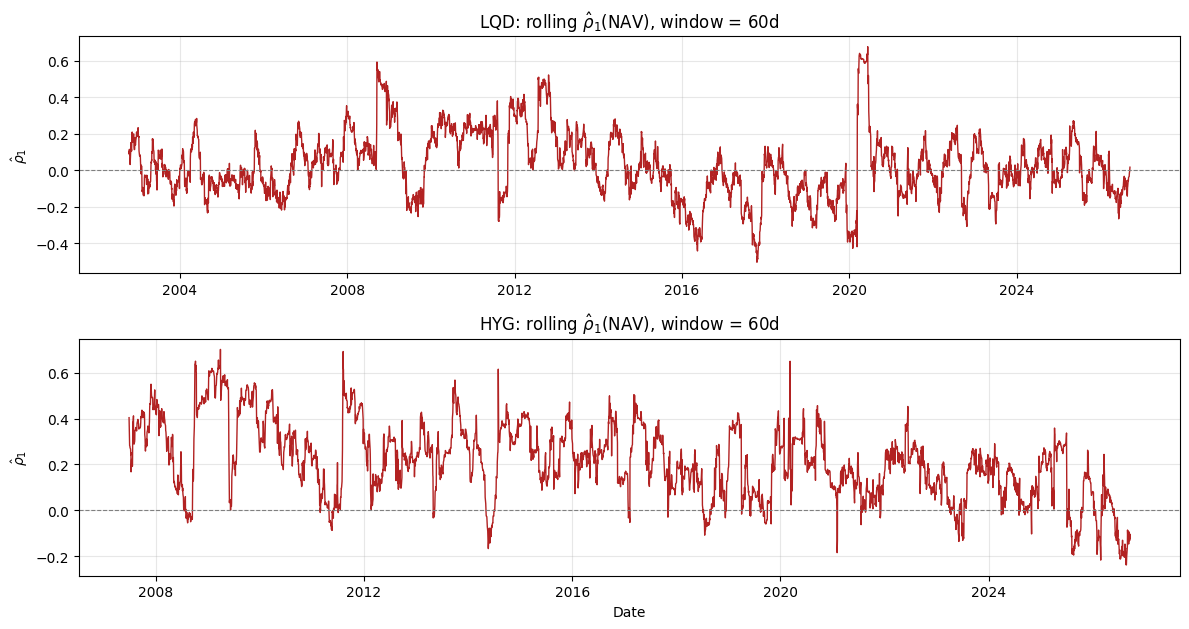

In [8]:
fig, axes = plt.subplots(len(real_rolling), 1, figsize=(12, 3.2 * len(real_rolling)), sharex=False)
if len(real_rolling) == 1:
    axes = [axes]

for ax, (ticker, df_roll) in zip(axes, real_rolling.items()):
    ax.plot(df_roll.index, df_roll["rho1"], color="firebrick", lw=1.0)
    ax.axhline(0, color="gray", lw=0.8, ls="--")
    ax.set_title(f"{ticker}: rolling $\\hat\\rho_1$(NAV), window = {ROLL_WINDOW}d")
    ax.set_ylabel(r"$\hat\rho_1$")

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig("../figures/smoothing_real_nav_rho1_en.png", dpi=130, bbox_inches="tight")
plt.show()

### 5.1 Why these numbers answer the research question

The connection is direct: the two models are the statistical translation
of the two sides of the liquidity-transformation mechanism, and the gap
between their properties is the empirical evidence that answers the
question.

The NAV model (Getmansky-Lo-Makarov smoothing) represents what happens if
the underlying is genuinely illiquid: the bonds in the basket don't trade
continuously, so the NAV computed every day uses stale/dated prices for
part of the holdings. This produces positive autocorrelation in NAV
returns ($\hat\rho_1 = \hat\phi$), and $\phi$ is effectively a quantitative
measure of how "old" the information in the basket is — the more illiquid
the underlying, the higher $\phi$. The Ljung-Box test confirms that this
autocorrelation is not sampling noise but a statistically solid pattern
($p<0.0001$ on LQD and HYG, table above), i.e.\ it confirms the underlying
is genuinely illiquid, not merely "presumed" to be.

The ETF price model ($r^P_t = r^\ast_t + \eta_t$, idiosyncratic noise)
instead represents the hypothesis that the ETF, despite holding that
underlying, trades like a liquid asset: a price that forms continuously on
the order-driven secondary market, independent of when the last bond in the
basket traded. If this hypothesis is true, $\hat\rho_1$(ETF) should be
statistically zero — and that is exactly what is observed in the Section 3
simulation (Ljung-Box never significant on the synthetic ETF), and
reproducible on real data in Section 6.

**Here is the answer to the research question:** if the ETF were simply
"the same asset" as the underlying basket, the ETF price should inherit the
same autocorrelation as the NAV. It does not. The gap
$\hat\rho_1(NAV) - \hat\rho_1(ETF) \approx \phi - 0$ is the quantitative
signature of liquidity transformation: it measures how much the ETF
wrapper is "decoupling" the liquidity observed on the secondary market from
the underlying's actual liquidity.

The mechanistic *why* behind this gap is what the main analysis (which you
present) develops: the market maker does continuous hedging with correlated
liquid proxies (rate futures, CDS indices, other liquid ETFs) instead of
trading the individual illiquid bonds on every quote — this is what lets it
quote continuously even when the underlying is not trading. The AP, through
creation/redemption on the primary market, acts only periodically to
realign the ETF price to the NAV via arbitrage, without every exchange
trade needing to touch the underlying. The order-driven secondary market
does the rest: continuous price discovery independent of the basket's
trading frequency.

> **In plain language.** The models don't explain the "how" (that's what
> you do with MM/AP/creation-redemption), they measure the "how much" —
> they put a number on a phenomenon that would otherwise remain purely
> narrative, and that number (the autocorrelation gap, statistically
> significant) is the empirical confirmation that liquidity transformation
> is actually happening in the real data of LQD and HYG.

## 6. Network extension: full NAV-vs-price comparison on real data

The most direct comparison — $\hat\rho_1(NAV)$ against $\hat\rho_1(P)$
**for the same fund**, exactly as in the Section 4 simulation — also
requires the ETF's exchange OHLCV (via `yfinance`), which is not reachable
over the network in this environment. The cell below is ready to be run
locally with `DEMO = False`: it downloads the OHLCV, recomputes price
returns, and applies exactly the same `rolling_autocorr_lag1` and
`rolling_variance_ratio` functions defined (and validated) above.

In [9]:
if not DEMO:
    import yfinance as yf

    real_gap_features = {}
    for ticker in TICKERS:
        if ticker not in real_nav_returns:
            print(f"{ticker}: no NAV data loaded, skipping.")
            continue

        # period="max" is essential here: yf.download() defaults to the last
        # 1 month of data when start/end are omitted, which is far shorter
        # than ROLL_WINDOW (60 days) - the rolling autocorrelation would then
        # be all-NaN and the plot below would come out empty.
        px_raw = yf.download(ticker, period="max", progress=False, auto_adjust=True)["Close"]
        # yfinance >= 1.x returns a MultiIndex-column DataFrame by default even
        # for a single ticker (multi_level_index=True), so ["Close"] can come
        # back as a 1-column DataFrame instead of a Series; pd.Series() on that
        # raises "Data must be 1-dimensional". Squeeze it down defensively so
        # this works across yfinance versions/defaults.
        if isinstance(px_raw, pd.DataFrame):
            px_raw = px_raw.iloc[:, 0]
        px = px_raw.dropna()
        px_ret = np.log(px).diff().dropna()
        px_ret.index = pd.to_datetime(px_ret.index).tz_localize(None)

        nav_ret = real_nav_returns[ticker].copy()
        nav_ret.index = pd.to_datetime(nav_ret.index).tz_localize(None)

        common_idx = px_ret.index.intersection(nav_ret.index)
        px_ret, nav_ret = px_ret.loc[common_idx], nav_ret.loc[common_idx]
        print(f"{ticker}: {len(common_idx)} overlapping trading days "
              f"({common_idx.min().date()} -> {common_idx.max().date()})")

        rho1_nav_roll_r = rolling_autocorr_lag1(nav_ret, ROLL_WINDOW)
        rho1_etf_roll_r = rolling_autocorr_lag1(px_ret, ROLL_WINDOW)
        gap_r = (rho1_nav_roll_r - rho1_etf_roll_r).dropna()

        real_gap_features[ticker] = pd.DataFrame({
            "rho1_nav": rho1_nav_roll_r,
            "rho1_etf": rho1_etf_roll_r,
            "gap": rho1_nav_roll_r - rho1_etf_roll_r,
        }).dropna()

        if real_gap_features[ticker].empty:
            print(f"{ticker}: no valid rows after the {ROLL_WINDOW}d rolling window - "
                  f"need at least {ROLL_WINDOW} days of overlapping NAV and ETF price "
                  "data. Check that yf.download() is fetching the full history "
                  "(period='max') and not just the last month.")
            continue

        fig, ax = plt.subplots(figsize=(12, 3.5))
        ax.plot(real_gap_features[ticker].index, real_gap_features[ticker]["rho1_nav"],
                label=r"$\hat\rho_1$(NAV)", color="firebrick")
        ax.plot(real_gap_features[ticker].index, real_gap_features[ticker]["rho1_etf"],
                label=r"$\hat\rho_1$(ETF price)", color="steelblue")
        ax.axhline(0, color="gray", lw=0.8, ls="--")
        ax.set_title(f"{ticker}: NAV vs ETF price, rolling autocorrelation ({ROLL_WINDOW}d)")
        ax.legend()
        plt.tight_layout()
        plt.savefig(f"../figures/smoothing_real_gap_{ticker.lower()}_en.png", dpi=130, bbox_inches="tight")
        plt.show()

    # Cross-fund comparison table, mirroring Section 5's NAV-only version
    if real_gap_features:
        rows = []
        for ticker, df_g in real_gap_features.items():
            rows.append({
                "Fund": ticker,
                "rho1(NAV) mean": round(df_g["rho1_nav"].mean(), 4),
                "rho1(ETF) mean": round(df_g["rho1_etf"].mean(), 4),
                "mean gap": round(df_g["gap"].mean(), 4),
            })
        display(pd.DataFrame(rows))
else:
    print("DEMO = True: section skipped. Set DEMO = False and run locally "
          "(requires 'pip install yfinance' and a network connection) for the "
          "NAV-vs-price comparison on real market data.")

DEMO = True: section skipped. Set DEMO = False and run locally (requires 'pip install yfinance' and a network connection) for the NAV-vs-price comparison on real market data.


## 7. Conclusions

**On the research question.** The two models fixed in Section 2 are not
just a statistical abstraction: they directly encode the main analysis's
two market levels. Model 2.1 (NAV) represents the primary/valuation side,
which inherits the bonds' illiquidity in the form of positive serial
autocorrelation. Model 2.2 (ETF price) represents the secondary/order-driven
side, where the market maker's continuous hedging keeps the price
statistically clean without requiring the underlying bonds to reprice. The
synthetic validation (Section 3) confirms that our estimators correctly
distinguish the two models, and the Ljung–Box test confirms that
distinction is statistically solid, not a sampling artifact; the real data
(Section 5) confirm that HYG's NAV is staler than LQD's, with formal
significance, consistent with high-yield credit's lower liquidity.

**How this connects to the main analysis.** The creation/redemption
mechanism, studied in the main analysis through the premium/discount
$\pi_t = P_t - NAV_t$, is precisely what keeps the two processes modeled
here from diverging indefinitely — but it acts discretely and
periodically (creation-unit blocks), not day by day. This is why $P_t$ and
$NAV_t$ can have such different statistical dynamics while remaining
anchored over the long run: the anchoring is guaranteed by arbitrage
(primary market), not by the two processes sharing the same day-to-day
statistical "memory" (which instead depends on the secondary market and
valuation, the primary market in a broader sense).

**Limitations.** The rolling window (60 days) is a design choice with the
usual bias/variance trade-off; the geometric smoothing model is a
convenient parametrization, not the only possible one; the full
NAV-versus-price comparison on real data requires the ETF's OHLCV
(network), not run in this environment — Section 5 (NAV only) remains a
real, self-contained test of the IG-vs-HY hypothesis regardless; a positive
$\hat\rho_1$ could in principle reflect other sources of autocorrelation
besides smoothing, not isolated here.

**Possible extensions.** A comparison against a third credit segment (EMB)
to check whether the IG < HY < EM staleness gradient holds; explicitly
simulating a breakdown of model 2.2 too (market maker that stops hedging
continuously), to complete the synthetic picture with the scenario where
the transformation genuinely fails; Ljung–Box testing on the rolling
windows as well (not just full-sample) to localize in time the periods
where the NAV's autocorrelation is statistically significant.